In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
germline_col = ["FID1", "IID1", "FID2", "IID2", "CHR", "SEG_START_BP", "SEG_END_BP", 
                "SEG_START_SNP", "SEG_END_SNP", "SNP", "LENGTH", "UNIT", "MISMATCH",
               "HOMOZYGOUS1", "HOMOZYGOUS2"]

In [86]:
def read_germline(population, min_m, bits):
    df = pd.read_csv(f"germline/chr10_{population}_germline_bits{bits}_minm{min_m}.match", delim_whitespace=True, header=None)
    df.columns = germline_col
    df_ibd = df.groupby(["IID1", "IID2"]).agg({"LENGTH": "sum", "UNIT": "first", "SNP": "count"}).reset_index()
    return df_ibd

def plink_plot(df):
    fig = plt.figure()
    plt.scatter(df["Z0"], df["Z1"])
    plt.xlabel("P(IBD=0)", size=15)
    plt.ylabel("P(IBD=1)", size=15)
    plt.show()
    
def compare_plink_germline(df_plink, df_germline, df_pedigree = None, plot = True, yax = "PI_HAT", save_path = None):
    if df_pedigree is None:
        df_full = (
            df_plink
            .merge(df_germline, how = "left", on = ["IID1", "IID2"])
            .fillna({"LENGTH": 0, "UNIT": "MB"})
        )
    
        if plot:
            fig = plt.figure()
            plt.scatter(df["LENGTH"], df["PI_HAT"])
            plt.xlabel("GERMLINE length", size=15)
            plt.ylabel(f"PLINK {yax.lower()}", size=15)
            if save_path:
                plt.savefig(save_path)
            plt.show()
        
    else:
        df_full = (
            df_plink
            .merge(df_germline, how = "left", on = ["IID1", "IID2"])
            .fillna({"LENGTH": 0, "UNIT": "MB"})
            .merge(df_pedigree, how = "left", on = ["IID1", "IID2"])
        )
        
        if plot:
            plt.figure(figsize=(7,5))
            sns.scatterplot(
                data = df_full,
                x = "LENGTH",
                y = "PI_HAT",
                hue = "Relationship")
            plt.xlabel("IBD Segment Length")
            plt.ylabel("Proportion IBD")
            plt.tight_layout()
            if save_path:
                plt.savefig(save_path)
            plt.show()
            
    return df_full

def plot_plink_density(df1, df2, label1, label2):
    plt.figure()
    sns.kdeplot(df1["PI_HAT"], color = "red", label = label1)
    sns.kdeplot(df2["PI_HAT"], color = "blue", label = label2)
    plt.xlabel("IBD Proportion")
    plt.legend(loc='upper right')
    plt.savefig(f"figs/plink_density_{label1}{label2}.png")
    plt.show()
    print(stats.ttest_ind(df1["PI_HAT"], df2["PI_HAT"], equal_var=False))
    
def plot_germline_density(df1, df2, label1, label2):
    plt.figure()
    sns.kdeplot(df1["LENGTH"], color = "red", label = label1)
    sns.kdeplot(df2["LENGTH"], color = "blue", label = label2)
    plt.xlabel("IBD LENGTH")
    plt.legend(loc='upper right')
    plt.savefig(f"figs/germline_density_{label1}{label2}.png")
    plt.show()
    print(stats.ttest_ind(df1["LENGTH"], df2["LENGTH"], equal_var=False))

## Data Loading

In [4]:
plink_lwk = pd.read_csv("plink/chr10_LWK_plink.genome", 
                 delim_whitespace=True)
plink_fin = pd.read_csv("plink/chr10_FIN_plink.genome", 
                 delim_whitespace=True)
plink_chs = pd.read_csv("plink/chr10_CHS_plink.genome", 
                 delim_whitespace=True)
plink_yri = pd.read_csv("plink/chr10_YRI_plink.genome",
                 delim_whitespace=True)

In [89]:
min_m = 0.01
germline_lwk = read_germline("LWK", bits = 16, min_m = min_m)
germline_fin = read_germline("FIN", bits = 16, min_m = min_m)
germline_chs = read_germline("CHS", bits = 16, min_m = min_m)
germline_yri = read_germline("YRI", bits = 16, min_m = min_m)

In [62]:
pedigree_chs = pd.read_csv("pedigree_CHS.csv")
pedigree_yri = pd.read_csv("pedigree_YRI.csv")

## Background Relatedness Study

The following plot offers a comparison of PLINK's IBD proportion measure for the LWK and FIN populations

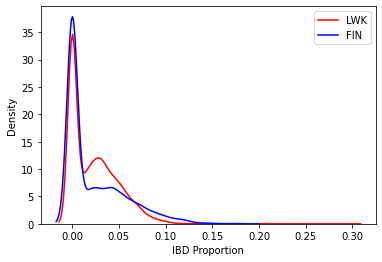

Ttest_indResult(statistic=0.30773231055302774, pvalue=0.7582928776653817)


In [33]:
plot_plink_density(plink_lwk, plink_fin, "LWK", "FIN")

The following plot offers a comparison of GERMLINE's total IBD match length for the LWK and FIN populations

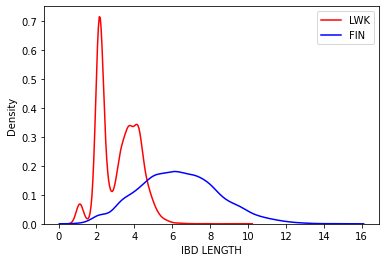

Ttest_indResult(statistic=-95.31620194856829, pvalue=0.0)


In [34]:
plot_germline_density(germline_lwk, germline_fin, "LWK", "FIN")

The following script provides an example for analyzing relative identification using PLINK and GERMLINE.

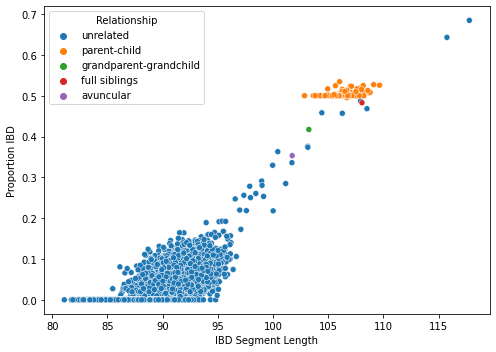

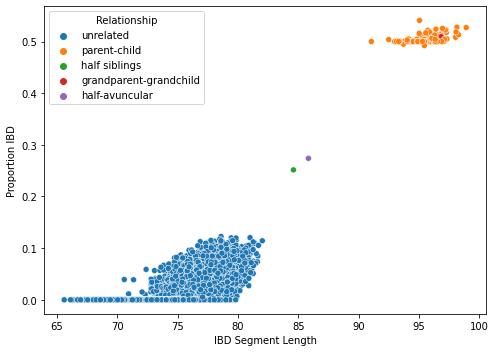

In [90]:
full_chs = compare_plink_germline(plink_chs, germline_chs, pedigree_chs, save_path = f"figs/comparison_CHS_{min_m}.png")
full_yri = compare_plink_germline(plink_yri, germline_yri, pedigree_yri, save_path = f"figs/comparison_YRI_{min_m}.png")